In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["NUMBA_THREADING_LAYER"] = "workqueue"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_MAX_ACTIVE_LEVELS"] = "1"
import stark as sk

In [2]:
# ==========================================
# 0. 初始化核心数据对象 HData
# ==========================================
print(">>> 初始化 HData 对象...")
resolutions = [ 50000,500000, 1000000,]
hdata = sk.HData(
    data_dir="/Users/ckw/warehouse/metacell/data/test_700_snm3c",
    output_dir="/Users/ckw/warehouse/metacell/stark/test_output",
    genome_reference_path="/Users/ckw/warehouse/metacell/hg19.fa.chrom.sizes",
    chrom_list=[f"chr{i}" for i in range(1, 23)],
    resolutions=resolutions
)

>>> 初始化 HData 对象...


In [3]:
hdata

HData object with 0 cells and 0 metacells
    resolutions: [50000, 500000, 1000000]
    obs: []
    views_pca: []
    views_umap: []
    views_embedding: []
    views_mat: []
    uns keys: []

In [4]:
# ==========================================
# 1. 执行数据预处理与加载
# ==========================================
print("\n>>> 1. 执行数据预处理与加载...")
sk.pp.process_and_load(
    hdata, 
    force_process=True, 
    cpu_num=10, 
    gpu_num=8
)


>>> 1. 执行数据预处理与加载...
====== calculating depth =======
Depth file already exists. Skipping depth calculation.
====== depth calculation completed =======
====== Processing multiple resolutions =======
====== Processing resolution: 50000 =======
Files for resolution 50000 already exist. Skipping processing.
====== Processing resolution: 500000 =======
Files for resolution 500000 already exist. Skipping processing.
====== Processing resolution: 1000000 =======
Files for resolution 1000000 already exist. Skipping processing.
✅ 数据底层处理 (stark_process) 完成。
✅ 数据已成功挂载到 HData 对象中。


In [5]:
lb = []
path = '/Users/ckw/warehouse/metacell/data/test_700_snm3c'
for val in os.listdir(path):
    if val.endswith('.pairs'):
        lb.append(val.split('.pairs')[0].split('_')[1])

In [6]:
hdata.obs['label'] = lb

In [7]:
hdata

HData object with 700 cells and 0 metacells
    resolutions: [50000, 500000, 1000000]
    obs: ['depth', 'label']
    views_pca: [50000, 500000, 1000000]
    views_umap: [50000, 500000, 1000000]
    views_embedding: [50000, 500000, 1000000]
    views_mat: []
    uns keys: []

In [8]:
# sk.pp.get_ps_curve_vec(hdata)

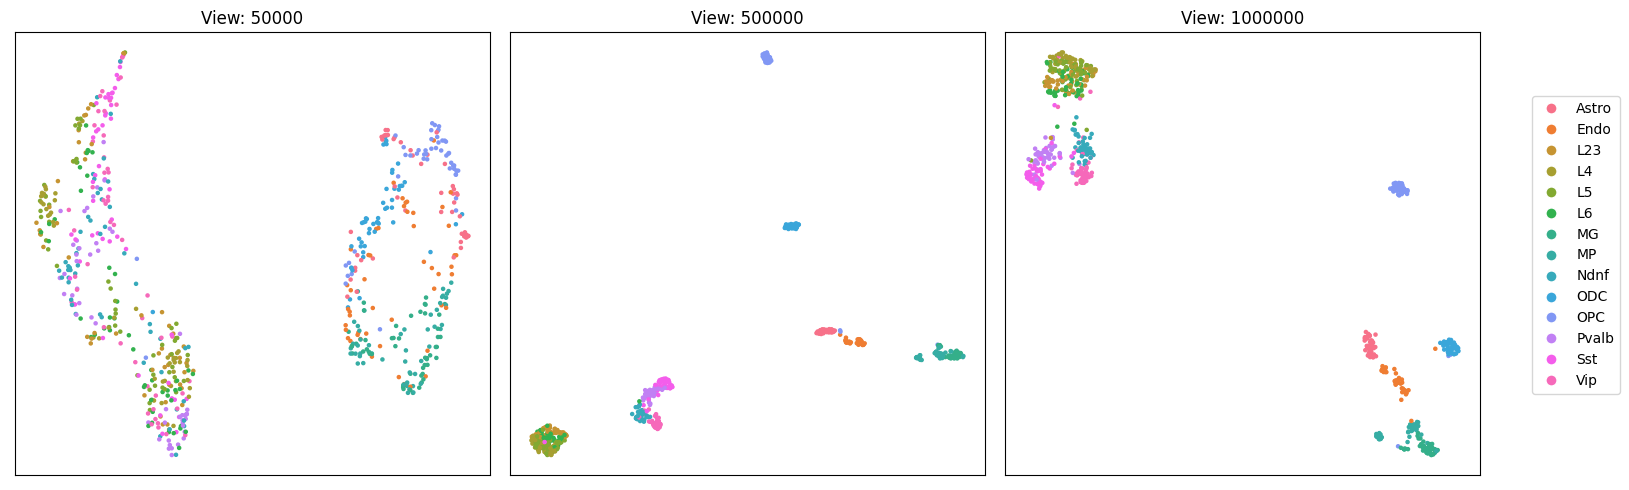

In [9]:
sk.pl.plot_views(hdata)

mean_depth:0.11M


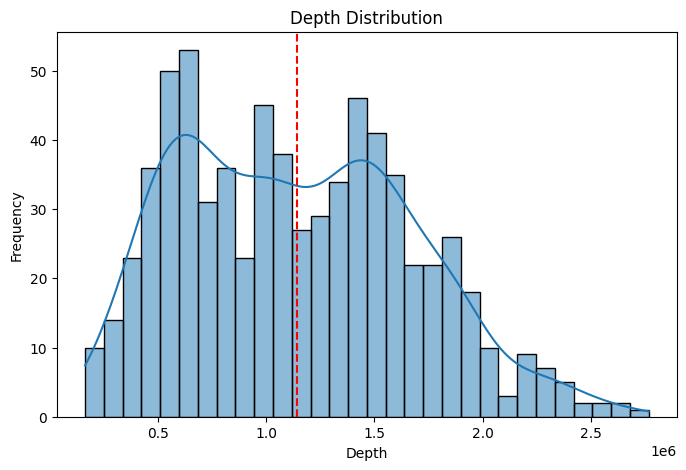

In [10]:
sk.pl.plot_depth_distribution(hdata)


>>> 2. 推荐 MetaCell 数量...
推荐 MetaCell 数量的目标测序深度范围: 10000000.00 - 100000000.00
正在构建 AnnData 并计算近邻图 (n_neighbors=30)...
正在执行 Leiden 聚类 (resolution=2.0)...
✅ 聚类完成，共发现 12 个聚类簇。

💡 基于 Leiden 聚类的推荐结果: 最终总 n_metacells 范围 = [12, 60]


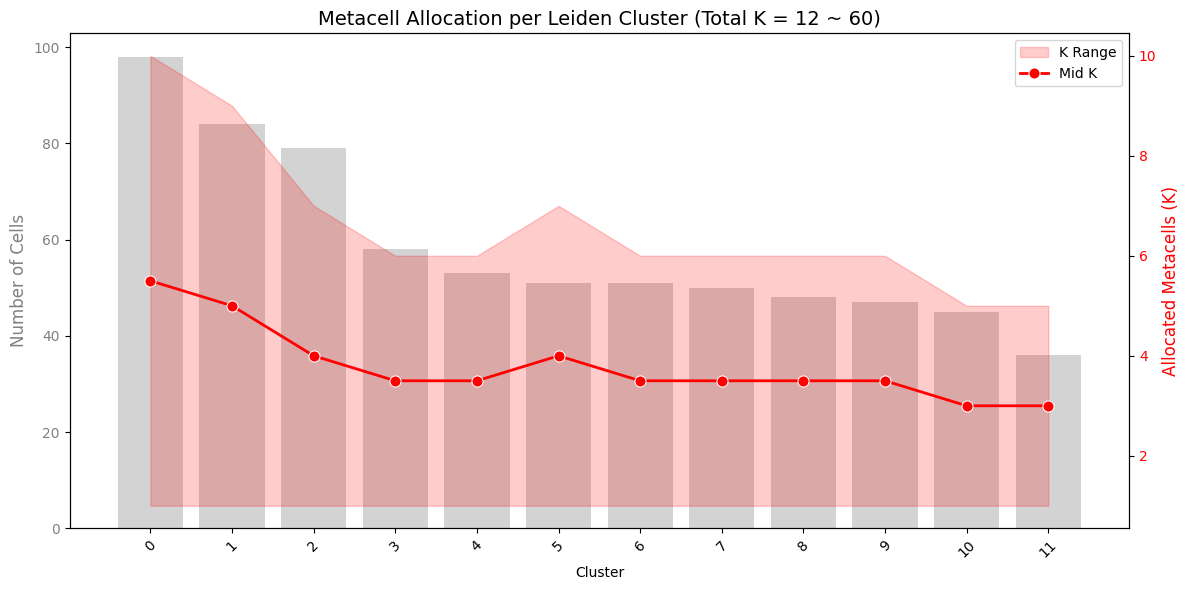

In [11]:
# ==========================================
# 2. 推荐 MetaCell 数量 (带原有参数)
# ==========================================
print("\n>>> 2. 推荐 MetaCell 数量...")
min_depth = 10000000
max_depth = 100000000
print(f"推荐 MetaCell 数量的目标测序深度范围: {min_depth:.2f} - {max_depth:.2f}")
min_k, max_k = sk.tl.recommend_metacell_num(
    hdata,
    target_depth_min=min_depth,  # 下限 20M
    target_depth_max=max_depth ,  # 上限 40M
    resolution_param=2.0,     # Leiden resolution
    n_neighbors=30,
    ref_view=500000,
    
)

In [12]:
# ==========================================
# 3. 初始化模型参数 (还原所有原有超参数)
# ==========================================
print("\n>>> 3. 初始化模型参数...")
sk.tl.init_model(
    hdata, 
    n_metacells=30,            # 目标 MetaCell 数量
    lambda_sparse=0.0000,      # 稀疏惩罚
    lambda_balance=0.1,       # 平衡惩罚
    lambda_consistency=0.001,  # 一致性惩罚
    max_iter=150,              # 最大迭代次数
    # --- scHi-C 深度优化参数 ---
    min_size_threshold=0.002,  # 重生阈值
    respawn_interval=10,       # 检查频率
    split_metric='pca',         # 分裂准则
    # weight_momentum=0.99,
)


>>> 3. 初始化模型参数...
✅ 模型参数初始化完成，目标 MetaCell 数量: 30


In [13]:
# ==========================================
# 4. 计算核矩阵
# ==========================================
print("\n>>> 4. 计算核矩阵...")
sk.tl.compute_kernels(hdata, )
# sk.tl.compute_kernels(hdata, use_ps=True)
# sk.tl.compute_kernels(hdata, use_ps=False)÷


>>> 4. 计算核矩阵...
步骤1: 构建核矩阵 (Cache Dir: None)
  [View 0] 开始内部计算 RBF 核矩阵 (Input: (700, 68))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:99: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)


  -> 核矩阵就绪: Shape=(700, 700), Sparsity=1.0
  [View 1] 开始内部计算 RBF 核矩阵 (Input: (700, 114))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:99: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)


  -> 核矩阵就绪: Shape=(700, 700), Sparsity=1.0
  [View 2] 开始内部计算 RBF 核矩阵 (Input: (700, 123))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:99: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)


  -> 核矩阵就绪: Shape=(700, 700), Sparsity=1.0



>>> 5. 初始化 Waypoints (K-Means++)...

步骤2: 参数初始化 (Data: kernel, Method: Micro-Clustering)
  正在合并核矩阵用于初始化...
  执行 MiniBatchKMeans (k=30)...
  [警告] 有效微簇少于目标数，强制使用最大的簇。
  最终选中 30 个 Waypoints


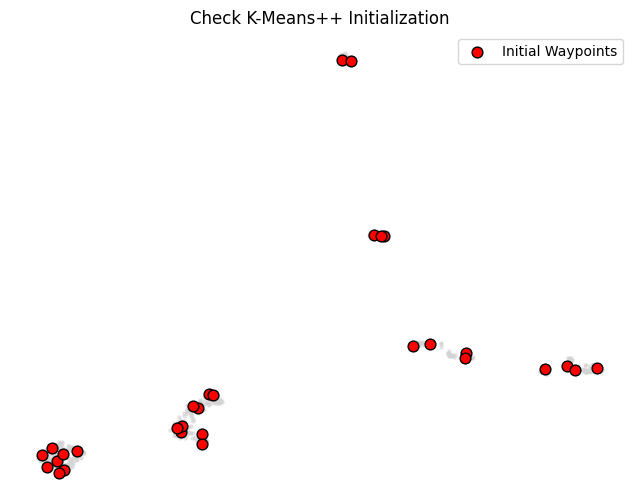

In [14]:
# ==========================================
# 5. 初始化 Waypoint (还原原有初始化参数)
# ==========================================
print("\n>>> 5. 初始化 Waypoints (K-Means++)...")
sk.tl.initialize_waypoints(
    hdata, 
    seed=32, 
    n_micro_clusters=30,       # 对应原代码中的 30
    ref_view_res=500000
)
sk.pl.plot_initialization(hdata,resolution=500000, title="Check K-Means++ Initialization")



In [15]:
# ==========================================
# 6. 核心拟合优化
# ==========================================
print("\n>>> 6. 开始模型拟合优化...")
sk.tl.fit(hdata, n_threads=10)


>>> 6. 开始模型拟合优化...

步骤4: 联合优化 (Split Metric: pca)
Iter   0 | Loss: 1530.2240 | Size Range: 22.2-25.3 | weight: [0.33333333 0.33333333 0.33333333] 
Iter  10 | Loss: 1352.7345 | Size Range: 21.9-25.0 | weight: [0.15040896 0.45365877 0.39593227] 
Iter  20 | Loss: 1325.6080 | Size Range: 22.1-25.7 | weight: [0.07470216 0.50648114 0.4188167 ] 
Iter  30 | Loss: 1318.0469 | Size Range: 22.1-24.3 | weight: [0.04913098 0.52386825 0.42700077] 
Iter  40 | Loss: 1307.2785 | Size Range: 22.1-24.9 | weight: [0.04068005 0.52689614 0.43242381] 
Iter  50 | Loss: 1303.2605 | Size Range: 22.0-26.5 | weight: [0.03748302 0.524425   0.43809198] 
Iter  60 | Loss: 1299.4572 | Size Range: 21.9-24.2 | weight: [0.03620684 0.52654823 0.43724493] 
Iter  70 | Loss: 1306.7686 | Size Range: 22.2-24.5 | weight: [0.03460448 0.52743377 0.43796175] 
Iter  80 | Loss: 1313.6850 | Size Range: 21.6-25.0 | weight: [0.03442142 0.52510712 0.44047145] 
Iter  90 | Loss: 1308.1108 | Size Range: 21.9-25.8 | weight: [0.03438257 0.5


>>> 7-10. 绘图与评估...


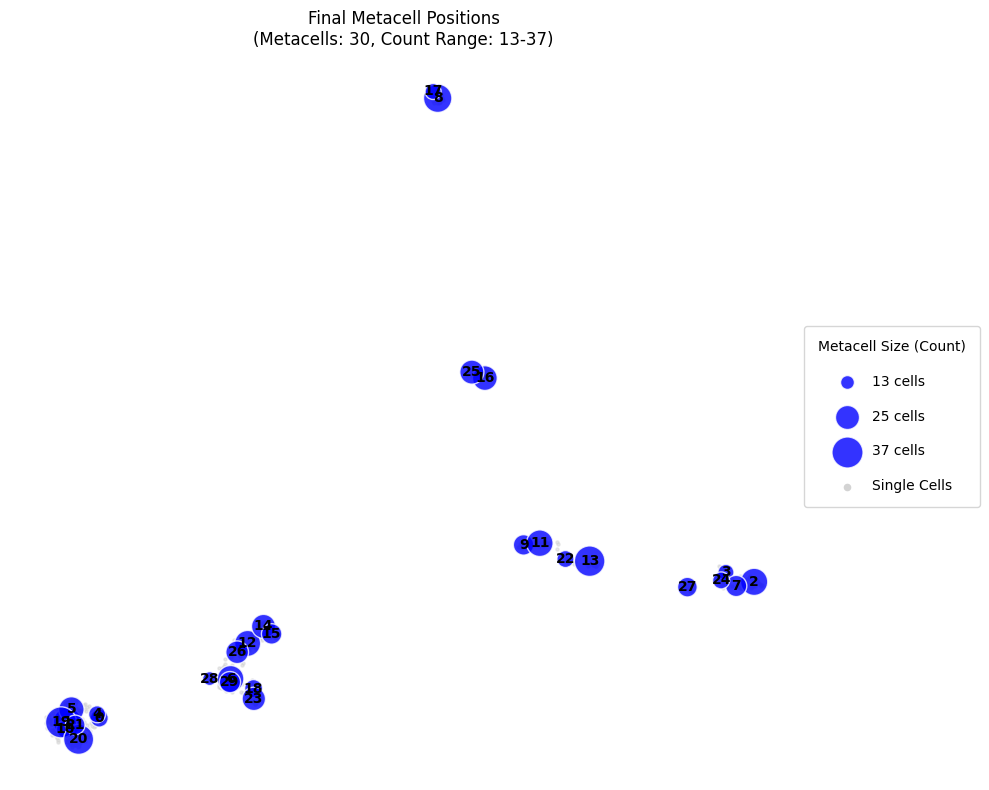

In [16]:


# ==========================================
# 7 - 10. 后续评估与可视化
# ==========================================
print("\n>>> 7-10. 绘图与评估...")
sk.pl.plot_metacells(hdata, resolution=500000, max_size=500, min_size=100,show_idx=True)


In [17]:
(hdata.model.kernels[1].toarray() >0.3).sum()


10082


正在计算评估指标...
✅ 指标计算完成！(发现 14 种细胞类型)
----------------------------------------
简单平均纯度 (Mean Purity)  : 0.8054
模型准确率 (Accuracy)      : 0.8029
全局加权分 (Global Score)  : 0.6259
过度融合指标 (WCOS)       : 0.9686
Hub 权重不纯度 (HWIS)     : 0.9926
----------------------------------------
✅ 评估指标计算完成，纯度得分(EP_v2等)已同步至 hdata.metacells。


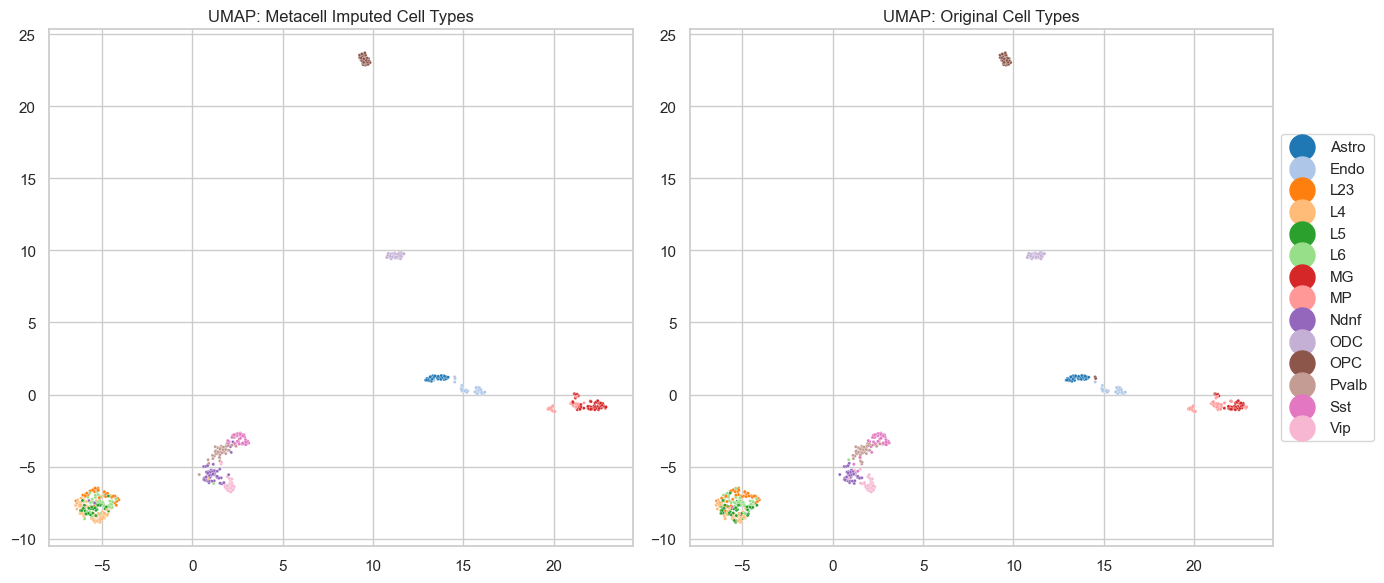


🎉 全流程运行完毕！


In [18]:
# 执行评估
purity_df, metrics = sk.tl.evaluate(hdata, hdata.obs['label'])

# 最终对比图
sk.pl.plot_umap_comparison(hdata, resolution=500000)

print("\n🎉 全流程运行完毕！")

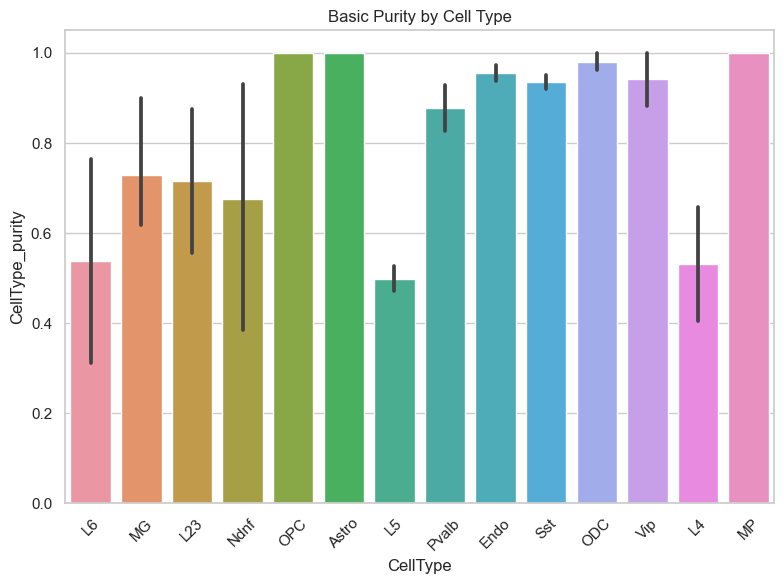

In [19]:
sk.pl.plot_basic_purity(hdata,)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


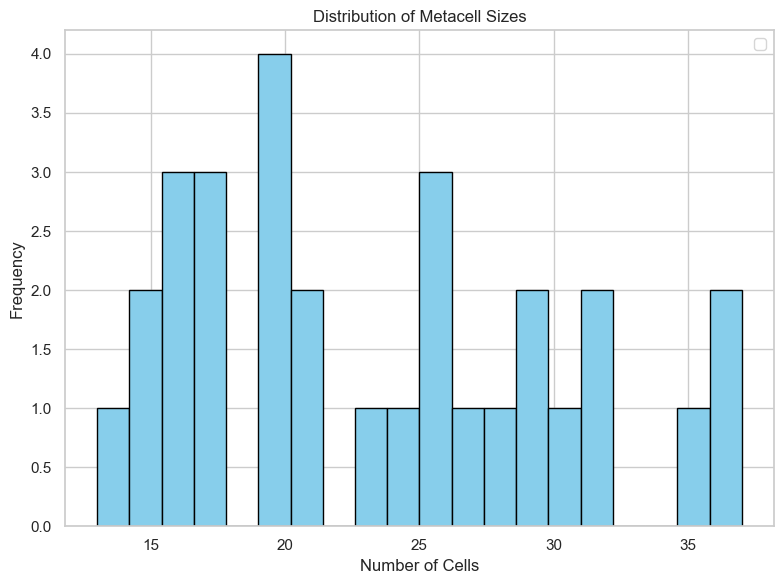

In [20]:
sk.pl.plot_metacell_sizes(hdata,)

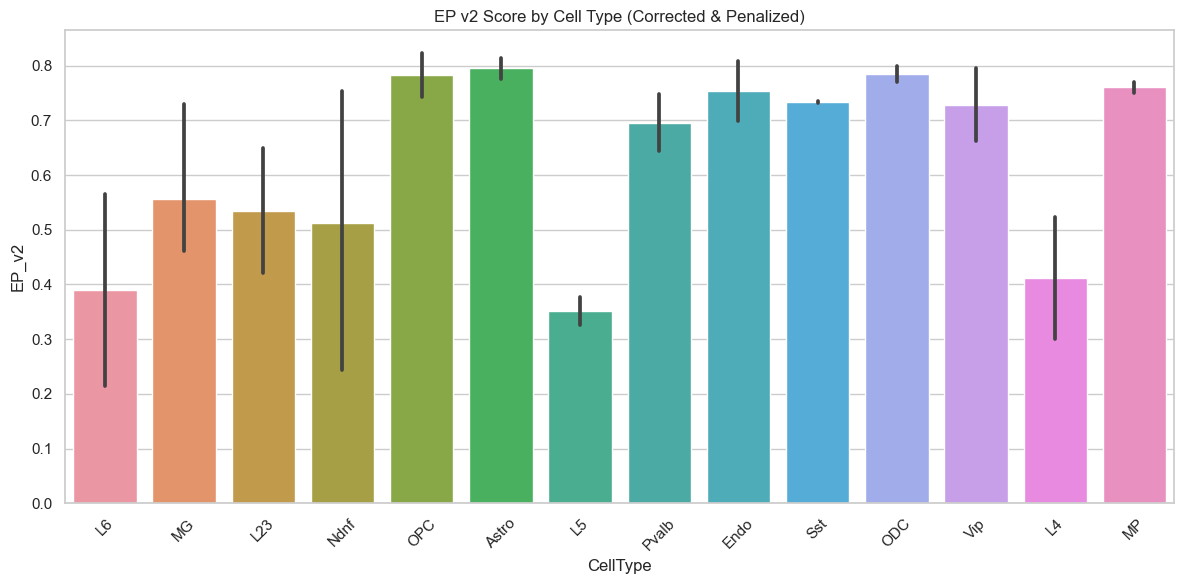

In [21]:
sk.pl.plot_ep_score(hdata)

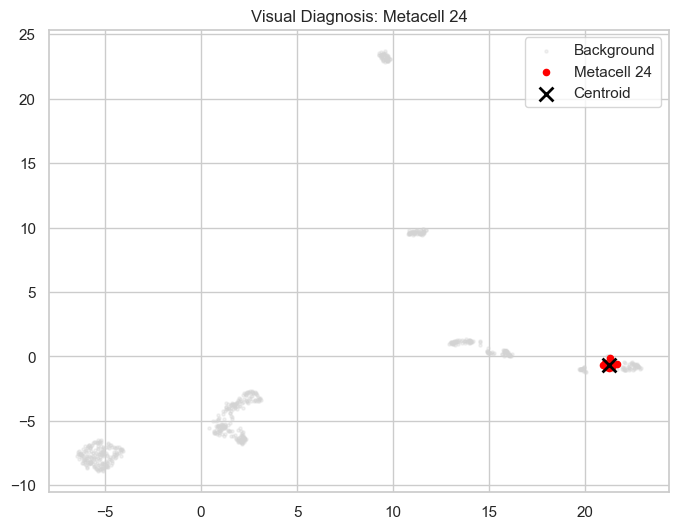

In [22]:
sk.pl.plot_specific_metacell(hdata, metacell_id=24, resolution=500000)


In [23]:
# sk.tl.aggregate_metacell_pairs(hdata,  n_jobs=2, force_aggregate=False, 
#                              convert_to_cool=True, convert_to_mcool=True,
#                              resolution=10000, mcool_resolutions=[ 50000, 100000,500000, 1000000,2000000], verbose=True)

# # ,2000000

In [24]:
# chrom = 'chr2'
# start = 169600000
# end = 174600000
# resolution = 50000

# sk.pl.plot_metacell_heatmap(hdata=hdata, 
#                             metacell_id=26,
#                             chrom=chrom,
#                             balance=False,
#                             resolution=50000,
#                             start=start,
#                             log1p=True,
#                             end=end,vmax=1)
# sk.pl.plot_celltype_heatmaps(hdata=hdata,
#                              chrom=chrom,
#                              cell_type='ODC',
#                             balance=False,
#                             resolution=50000,
#                             start=start,
#                             cell_type_col='dominant_label',
#                             ncols=3,
#                             end=end,vmax=1)

In [25]:
# sk.pl.plot_celltype_heatmaps(hdata=hdata,
#                              chrom=chrom,
#                              cell_type='OPC',
#                             balance=False,
#                             resolution=50000,
#                             start=start,
#                             cell_type_col='dominant_label',
#                             ncols=3,
#                             vmax=1,
#                             log1p=True,
#                             fill_diagonal_zero=True,
#                             end=end)

In [26]:
hdata

HData object with 700 cells and 30 metacells
    resolutions: [50000, 500000, 1000000]
    obs: ['depth', 'label', 'metacell']
    views_pca: [50000, 500000, 1000000]
    views_umap: [50000, 500000, 1000000]
    views_embedding: [50000, 500000, 1000000]
    views_mat: []
    uns keys: ['recommended_k', 'purity_df', 'metrics', 'eval_df_cache', 'avg_size_cache', 'thre_cache', 'accuracy', 'global_score', 'wcos', 'hwis']
    metacells: ['CellType', 'CellType_purity', 'cell_num', 'w_min', 'w_max', 'P_adj', 'EP_v2']
    metacell_data keys: []
    model: MultiViewSEACells (trained: True)